# Assignment 2

**First name Last name | Student ID | Group**
<br><br>
Task: comparing different ML method performances on public dataset of house prices

Dataset: House Prices, https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data

Dataset contains the following files:
*   train.csv: The training dataset containing house features and their corresponding sale prices.
*   test.csv: The testing dataset containing house features but without the sale prices.
*   data_description.txt: A file detailing the descriptions of each feature included in the dataset.
*   List item

## Imports

In [ ]:
# Imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os
import warnings
from scipy import stats
from sklearn.cluster import KMeans
from pandas.api.types import CategoricalDtype
from sklearn.model_selection import KFold, cross_val_score
from sklearn.feature_selection import mutual_info_regression
from xgboost import XGBRegressor
from sklearn.decomposition import PCA
warnings.filterwarnings('ignore')

In [ ]:
train_df = pd.read_csv('train.csv')
test_df = pd.read_csv('test.csv')

# **Dataset preparation**

Before we can do any analysis, we need to preprocess the data to get it in a form suitable for model building. We'll need to:

Load: Load the data from CSV files

Clean: Clean the data to fix any errors or inconsistencies

Encode: Encode the statistical data type (numeric, categorical)

Impute: Impute any missing values

## Exploring data

In [ ]:
display(train_df.head())
print(train_df.info())
print(train_df.describe)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [ ]:
display(test_df.head())
print(test_df.info())

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition
0,1461,20,RH,80.0,11622,Pave,NaN,Reg,Lvl,AllPub,...,120,0,NaN,MnPrv,NaN,0,6,2010,WD,Normal
1,1462,20,RL,81.0,14267,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,Gar2,12500,6,2010,WD,Normal
2,1463,60,RL,74.0,13830,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,MnPrv,NaN,0,3,2010,WD,Normal
3,1464,60,RL,78.0,9978,Pave,NaN,IR1,Lvl,AllPub,...,0,0,NaN,NaN,NaN,0,6,2010,WD,Normal
4,1465,120,RL,43.0,5005,Pave,NaN,IR1,HLS,AllPub,...,144,0,NaN,NaN,NaN,0,1,2010,WD,Normal


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1459 entries, 0 to 1458
Data columns (total 80 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1459 non-null   int64  
 1   MSSubClass     1459 non-null   int64  
 2   MSZoning       1455 non-null   object 
 3   LotFrontage    1232 non-null   float64
 4   LotArea        1459 non-null   int64  
 5   Street         1459 non-null   object 
 6   Alley          107 non-null    object 
 7   LotShape       1459 non-null   object 
 8   LandContour    1459 non-null   object 
 9   Utilities      1457 non-null   object 
 10  LotConfig      1459 non-null   object 
 11  LandSlope      1459 non-null   object 
 12  Neighborhood   1459 non-null   object 
 13  Condition1     1459 non-null   object 
 14  Condition2     1459 non-null   object 
 15  BldgType       1459 non-null   object 
 16  HouseStyle     1459 non-null   object 
 17  OverallQual    1459 non-null   int64  
 18  OverallC

##  Filling missed values, imputing

In [ ]:
def clean_data(df):
  df["Exterior2nd"] = df["Exterior2nd"].replace({"Brk Cmn": "BrkComm"})
    # column names starting from numbers are not preferred, so we will replace them
  df.rename(columns={
        "1stFlrSF": "FirstFlrSF",
        "2ndFlrSF": "SecondFlrSF",
        "3SsnPorch": "Threeseasonporch",
  }, inplace=True,
  )
  # replace garage built NaN with the year built of the house
  df["GarageYrBlt"] = df["GarageYrBlt"].where(df.GarageYrBlt <= 2010, df.YearBuilt)

  # some data should have just "No" as option, but instead it was "NaN", so we'll correct it
  none_features = ['PoolQC','BsmtQual', 'BsmtCond', 'BsmtExposure', 'FireplaceQu',
                  'GarageFinish', 'GarageQual', 'GarageCond', 'Fence', 'Alley',
                  'BsmtFinType1', 'BsmtFinType2', 'MasVnrType', 'GarageType', 'MiscFeature']
  for col in none_features:
      df[col] = df[col].fillna('No')

  # 0 imputing missing values:
  missing_features_1 = ['MasVnrArea', 'BsmtFinSF1', 'BsmtFinSF2', 'BsmtUnfSF','TotalBsmtSF',
                        'BsmtFullBath', 'BsmtHalfBath','GarageArea', 'GarageCars']

  for col in missing_features_1:
      df[col] = df[col].fillna(0)

  # 0 imputing with mode:
  missing_features_2 = ['MSZoning', 'Electrical', 'KitchenQual', 'Exterior1st', 'Exterior2nd',
                        'SaleType']

  for col in missing_features_2:
      df[col] = df[col].fillna(df[col].mode()[0])

  # LotFrontage:
  df["LotFrontage"] = df.groupby("Neighborhood")["LotFrontage"].transform(
      lambda x: x.fillna(x.mode()[0]))
  # Utilities (all values are AllPub, except several being different and 2 NaN, so it is useless):
  df = df.drop(['Utilities'], axis=1)
  # Functional, fill NaN with typical:
  df['Functional'] = df['Functional'].fillna('Typ')

  print(df.isnull().sum().sort_values(ascending=False).head(25))

  return df

train_df = clean_data(train_df)
test_df = clean_data(test_df)

Id               0
MSSubClass       0
GarageYrBlt      0
GarageType       0
FireplaceQu      0
Fireplaces       0
Functional       0
TotRmsAbvGrd     0
KitchenQual      0
KitchenAbvGr     0
BedroomAbvGr     0
HalfBath         0
FullBath         0
BsmtHalfBath     0
BsmtFullBath     0
GrLivArea        0
LowQualFinSF     0
SecondFlrSF      0
FirstFlrSF       0
GarageFinish     0
GarageCars       0
GarageArea       0
PoolQC           0
SaleCondition    0
SaleType         0
dtype: int64
Id              0
BedroomAbvGr    0
GarageType      0
FireplaceQu     0
Fireplaces      0
Functional      0
TotRmsAbvGrd    0
KitchenQual     0
KitchenAbvGr    0
HalfBath        0
GarageFinish    0
FullBath        0
BsmtHalfBath    0
BsmtFullBath    0
GrLivArea       0
LowQualFinSF    0
SecondFlrSF     0
FirstFlrSF      0
GarageYrBlt     0
GarageCars      0
CentralAir      0
PoolArea        0
SaleType        0
YrSold          0
MoSold          0
dtype: int64


## Observing Correlation

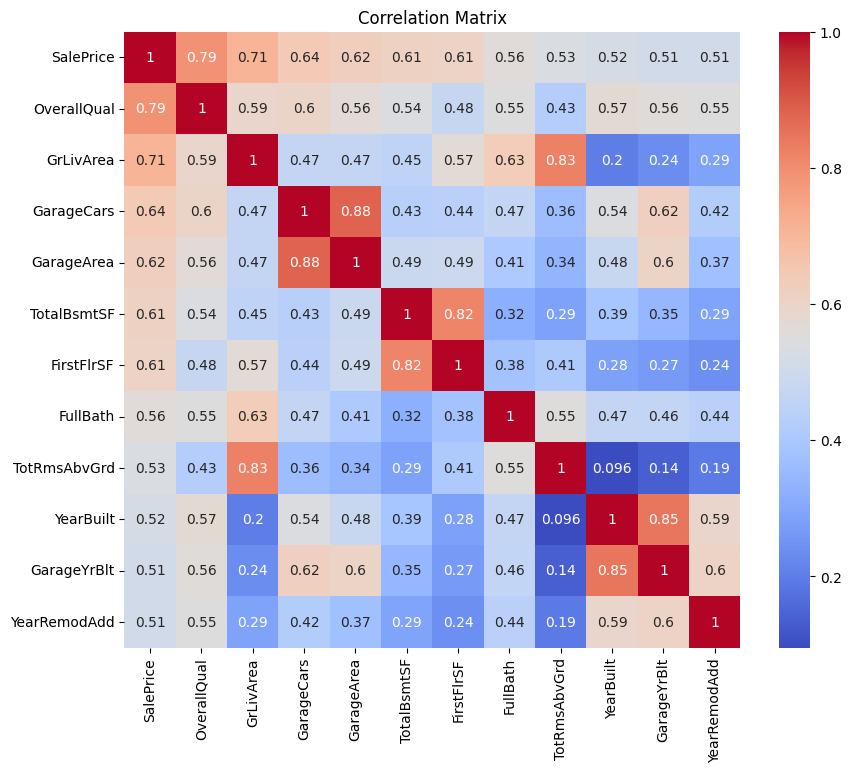

In [ ]:
train_corr = train_df.select_dtypes(include=[np.number])

corr = train_corr.corr()

corr_sorted = corr['SalePrice'].abs().sort_values(ascending=False)
corr_high = corr_sorted[corr_sorted>0.5].index

corr = corr.loc[corr_high, corr_high]

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', square=True)
plt.title('Correlation Matrix')
plt.show()

OverallQual and GrLivArea have the highest correlation with SalePrice.

GarageCars and GarageArea have a correlation of 0.88, that brings redundancy and unstable coefficients.

Next, we will check all features for correlation using Pearson for Numerical, Cramér's V for Categorical features.

In [ ]:
from scipy.stats import chi2_contingency

def cramers_v(confusion_matrix):
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum()
    return np.sqrt(chi2 / (n * (min(confusion_matrix.shape) - 1)))

def calculate_feature_correlations(X, y):
    numerical_corr = {}
    categorical_corr = {}

    # Pearson Correlation for numerical features
    for col in X.select_dtypes(include=['float64', 'int64']).columns:
        corr = np.corrcoef(X[col], y)[0, 1]
        numerical_corr[col] = abs(corr)

    # Cramér's V for categorical features
    for col in X.select_dtypes(include=['object', 'category']).columns:
        confusion_matrix = pd.crosstab(X[col], y)
        categorical_corr[col] = cramers_v(confusion_matrix.to_numpy())

    return numerical_corr, categorical_corr


In [ ]:
X = train_df.drop(columns=['SalePrice'])
y = train_df['SalePrice']

numerical_corr, categorical_corr = calculate_feature_correlations(X, y)

combined_corr = {**numerical_corr, **categorical_corr}
sorted_corr = pd.Series(combined_corr).sort_values(ascending=False)
print("Feature Correlations with Target:\n", sorted_corr)

# drop features with correlation close to 0
low_corr_features = sorted_corr[sorted_corr < 0.022].index
print("Features to drop (correlation < 0.01):", list(low_corr_features))
X_cleaned = X.drop(columns=low_corr_features)

Feature Correlations with Target:
 ExterQual       0.806617
KitchenQual     0.801226
OverallQual     0.790982
Street          0.780022
BsmtQual        0.779901
                  ...   
LowQualFinSF    0.025606
Id              0.021917
MiscVal         0.021190
BsmtHalfBath    0.016844
BsmtFinSF2      0.011378
Length: 79, dtype: float64
Features to drop (correlation < 0.01): ['Id', 'MiscVal', 'BsmtHalfBath', 'BsmtFinSF2']


We will drop the features that has the correlation less than 'Id', because we know for sure that Id doesn't affect in any way, meaning features with correlation less than it definetly won't affect. Apply those to both train and test.

In [ ]:
train = train_df.drop(columns=low_corr_features)
test = test_df.drop(columns=low_corr_features)

In [ ]:
print(train.shape)
print(test.shape)

(1460, 76)
(1459, 75)


## Woking with outliers

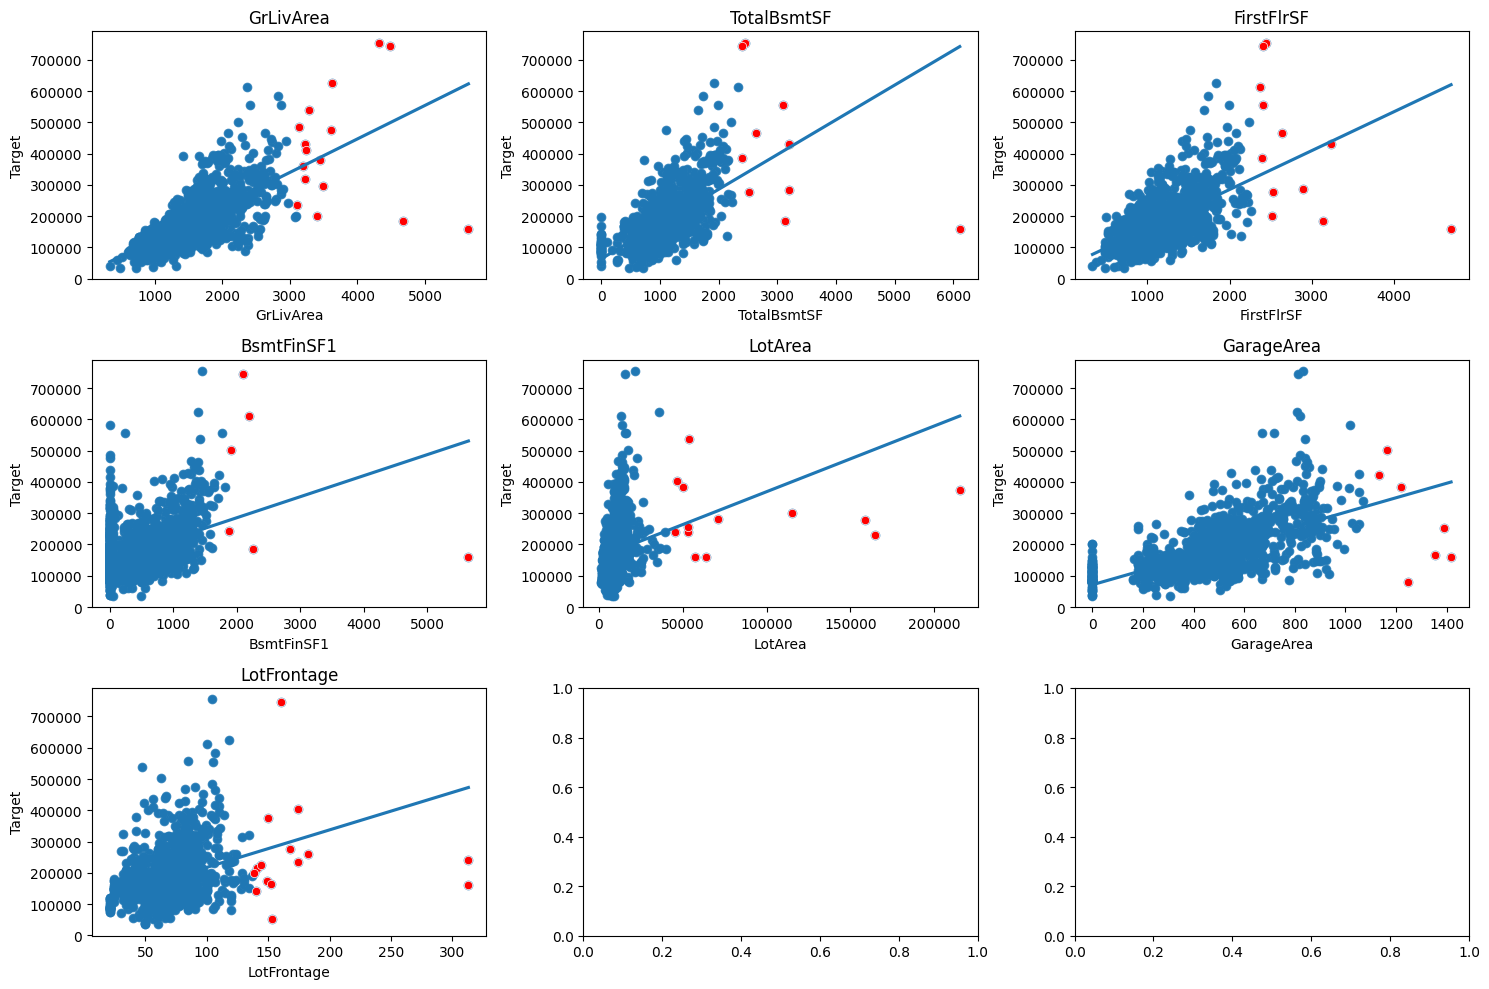

In [ ]:
features = ['GrLivArea', 'TotalBsmtSF', 'FirstFlrSF', 'BsmtFinSF1', 'LotArea', 'GarageArea', 'LotFrontage']

fig, axs = plt.subplots(nrows=3, ncols=3, figsize=(15, 10))

for i, feature in enumerate(features):
    row = i // 3
    col = i % 3
    ax = axs[row, col]

    sns.scatterplot(x=feature, y='SalePrice', data=train, ax=ax)

    sns.regplot(x=feature, y='SalePrice', data=train, ax=ax, ci=None)

    # identify outliers using Z-score method
    z_scores = np.abs(stats.zscore(train[feature]))
    outliers = train[z_scores > 3]

    sns.scatterplot(x=feature, y='SalePrice', data=outliers, ax=ax, color='red')

    ax.set_title(feature)
    ax.set_xlabel(feature)
    ax.set_ylabel('Target')

plt.tight_layout()
plt.show()

In [ ]:
def delete_outliers(df):
    df = df[df['GrLivArea'] < 4500]
    df = df[df['LotArea'] < 100000]
    df = df[df['TotalBsmtSF'] < 3000]
    df = df[df['FirstFlrSF'] < 2500]
    df = df[df['BsmtFinSF1'] < 2000]
    df = df[df['LotFrontage'] < 150]
    return df

In [ ]:
train = delete_outliers(train)
test = delete_outliers(test)

In [ ]:
print(train.shape)
print(test.shape)

(1438, 76)
(1442, 75)


We will add the new column, price category for the classification task, I thought it would be better to add it here, before normalizing the sale price. Let's divide the saleprice into 3 categories: low, high, and medium using interquartile range metrics. Less than 25% - low, between 25-75% - medium, 75% - high.


In [ ]:
import pandas as pd

Q1 = train['SalePrice'].quantile(0.25)  # 25th percentile
Q3 = train['SalePrice'].quantile(0.75)  # 75th percentile

def assign_category(price):
    if price < Q1:
        return 'Low'
    elif price <= Q3:
        return 'Medium'
    else:
        return 'High'

train['SaleHouseCat'] = train['SalePrice'].apply(assign_category)

print(train['SaleHouseCat'].value_counts())

SaleHouseCat
Medium    720
Low       360
High      358
Name: count, dtype: int64


In [ ]:
train.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SaleHouseCat
0,60,RL,65.0,8450,Pave,No,Reg,Lvl,Inside,Gtl,...,0,No,No,No,2,2008,WD,Normal,208500,Medium
1,20,RL,80.0,9600,Pave,No,Reg,Lvl,FR2,Gtl,...,0,No,No,No,5,2007,WD,Normal,181500,Medium
2,60,RL,68.0,11250,Pave,No,IR1,Lvl,Inside,Gtl,...,0,No,No,No,9,2008,WD,Normal,223500,High
3,70,RL,60.0,9550,Pave,No,IR1,Lvl,Corner,Gtl,...,0,No,No,No,2,2006,WD,Abnorml,140000,Medium
4,60,RL,84.0,14260,Pave,No,IR1,Lvl,FR2,Gtl,...,0,No,No,No,12,2008,WD,Normal,250000,High


## Target Variable Normalization


 mu = 178810.32 and sigma = 75654.77



Text(0.5, 1.0, 'SalePrice distribution')

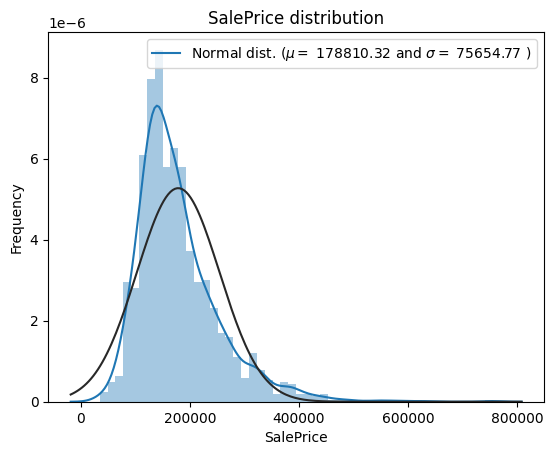

In [ ]:
from scipy.stats import norm, skew

sns.distplot(train['SalePrice'] , fit=norm);

# Get the fitted parameters used by the function
(mu, sigma) = norm.fit(train['SalePrice'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

It is pretty right skewed, so we will normalize it. This will be benefitial for the model trainings (especially for regression models).


 mu = 12.02 and sigma = 0.39



Text(0.5, 1.0, 'SalePrice distribution')

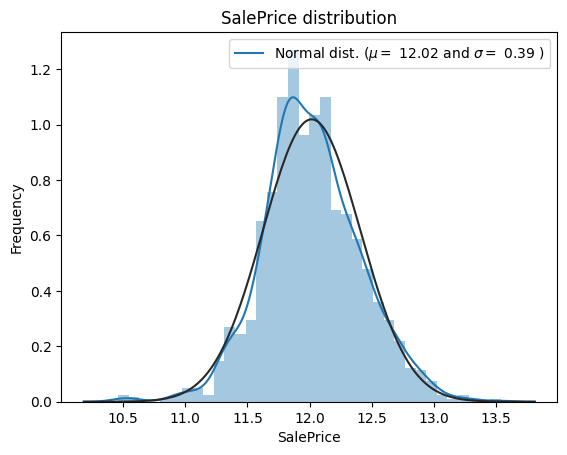

In [ ]:
train["SalePrice"] = np.log1p(train["SalePrice"])

sns.distplot(train['SalePrice'] , fit=norm);

(mu, sigma) = norm.fit(train['SalePrice'])
print( '\n mu = {:.2f} and sigma = {:.2f}\n'.format(mu, sigma))

plt.legend(['Normal dist. ($\mu=$ {:.2f} and $\sigma=$ {:.2f} )'.format(mu, sigma)],
            loc='best')
plt.ylabel('Frequency')
plt.title('SalePrice distribution')

In [ ]:
train.tail()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,...,PoolArea,PoolQC,Fence,MiscFeature,MoSold,YrSold,SaleType,SaleCondition,SalePrice,SaleHouseCat
1455,60,RL,62.0,7917,Pave,No,Reg,Lvl,Inside,Gtl,...,0,No,No,No,8,2007,WD,Normal,12.072547,Medium
1456,20,RL,85.0,13175,Pave,No,Reg,Lvl,Inside,Gtl,...,0,No,MnPrv,No,2,2010,WD,Normal,12.254868,Medium
1457,70,RL,66.0,9042,Pave,No,Reg,Lvl,Inside,Gtl,...,0,No,GdPrv,Shed,5,2010,WD,Normal,12.493133,High
1458,20,RL,68.0,9717,Pave,No,Reg,Lvl,Inside,Gtl,...,0,No,No,No,4,2010,WD,Normal,11.864469,Medium
1459,20,RL,75.0,9937,Pave,No,Reg,Lvl,Inside,Gtl,...,0,No,No,No,6,2008,WD,Normal,11.901590,Medium


## Feature Engineering with Encoding

We will use Label Encoder with features that have some sort of ranking, while One-hot-encoding will be used with just simply categorical features.

In [ ]:
ntrain = train.shape[0]
ntest = test.shape[0]
y_train_reg = train.SalePrice.values
y_train_class = train.SaleHouseCat.values
all_data = pd.concat((train, test)).reset_index(drop=True)
all_data.drop(['SalePrice', 'SaleHouseCat'], axis=1, inplace=True)
print("all_data size is : {}".format(all_data.shape))
print("all_data size is : {}".format(y_train_reg.shape))
print("all_data size is : {}".format(y_train_class.shape))

all_data size is : (2880, 75)
all_data size is : (1438,)
all_data size is : (1438,)


In [ ]:
print(ntrain)

1438


In [ ]:
# Transforming some numerical variables that are really categorical
all_data['MSSubClass'] = all_data['MSSubClass'].apply(str)
all_data['OverallCond'] = all_data['OverallCond'].astype(str)
all_data['YearRemodAdd'] = all_data['OverallQual'].astype(str)
all_data['YrSold'] = all_data['YrSold'].astype(str)
all_data['MoSold'] = all_data['MoSold'].astype(str)
all_data['YearRemodAdd'] = all_data['YearRemodAdd'].astype(str)

In [ ]:
from sklearn.preprocessing import LabelEncoder

cols = ('FireplaceQu', 'BsmtQual', 'BsmtCond', 'GarageQual', 'GarageCond',
        'ExterQual', 'ExterCond','HeatingQC', 'PoolQC', 'KitchenQual', 'BsmtFinType1',
        'BsmtFinType2', 'Functional', 'Fence', 'BsmtExposure', 'GarageFinish', 'LandSlope',
        'LotShape', 'PavedDrive', 'Street', 'Alley', 'CentralAir', 'MSSubClass', 'OverallCond',
        'YrSold', 'MoSold', 'YearRemodAdd', 'YearRemodAdd')

for c in cols:
    lbl = LabelEncoder()
    lbl.fit(list(all_data[c].values))
    all_data[c] = lbl.transform(list(all_data[c].values))

print('Shape all_data: {}'.format(all_data.shape))

Shape all_data: (2880, 75)


As area related features are important, we will add one additional feature, the total area.

In [ ]:
all_data['TotalSF'] = all_data['TotalBsmtSF'] + all_data['FirstFlrSF'] + all_data['SecondFlrSF']

In [ ]:
print('Shape all_data: {}'.format(all_data.shape))

Shape all_data: (2880, 76)


In [ ]:
numeric_feats = all_data.dtypes[all_data.dtypes != "object"].index

# check the skew of all numerical features (we did this with the target variable above)
skewed_feats = all_data[numeric_feats].apply(lambda x: skew(x.dropna())).sort_values(ascending=False)
print("\nSkew in numerical features: \n")
skewness = pd.DataFrame({'Skew' :skewed_feats})
skewness.head(10)


Skew in numerical features: 



,Skew
PoolArea,21.885763
LowQualFinSF,12.252995
Threeseasonporch,11.298109
LandSlope,5.055889
KitchenAbvGr,4.287173
EnclosedPorch,4.001164
ScreenPorch,3.967158
LotArea,3.627019
MasVnrArea,2.617399
OpenPorchSF,2.513715


In [ ]:
skewness = skewness[abs(skewness) > 0.75]
print("There are {} skewed numerical features to Box Cox transform".format(skewness.shape[0]))

from scipy.special import boxcox1p
skewed_features = skewness.index
lam = 0.15
for feat in skewed_features:
    #all_data[feat] += 1
    all_data[feat] = boxcox1p(all_data[feat], lam)

There are 56 skewed numerical features to Box Cox transform


In [ ]:
all_data.head()

,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,LotConfig,LandSlope,...,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MoSold,YrSold,SaleType,SaleCondition,TotalSF
0,2.885846,RL,5.831328,19.212182,0.730463,0.730463,1.540963,Lvl,Inside,0.0,...,0.0,0.0,1.194318,1.820334,No,1.820334,1.194318,WD,Normal,14.976591
1,2.055642,RL,6.221214,19.712205,0.730463,0.730463,1.540963,Lvl,FR2,0.0,...,0.0,0.0,1.194318,1.820334,No,2.440268,0.730463,WD,Normal,14.923100
2,2.885846,RL,5.914940,20.347241,0.730463,0.730463,0.000000,Lvl,Inside,0.0,...,0.0,0.0,1.194318,1.820334,No,3.011340,1.194318,WD,Normal,15.149678
3,3.011340,RL,5.684507,19.691553,0.730463,0.730463,0.000000,Lvl,Corner,0.0,...,0.0,0.0,1.194318,1.820334,No,1.820334,0.000000,WD,Abnorml,14.857121
4,2.885846,RL,6.314735,21.325160,0.730463,0.730463,0.000000,Lvl,FR2,0.0,...,0.0,0.0,1.194318,1.820334,No,1.540963,1.194318,WD,Normal,15.852312


In [ ]:
all_data = pd.get_dummies(all_data)
print(all_data.shape)

(2880, 217)


In [ ]:
train = all_data[:ntrain]
test = all_data[ntrain:]

In [ ]:
print(train.shape)
print(test.shape)

(1438, 217)
(1442, 217)


In [ ]:
y_train_class = lbl.fit_transform(y_train_class)

# Step 1: Setting Performance Metrics

For **unsupervised learning models**:

*Silhouette Score* - provides a direct measure of cluster quality for KMeans and DBSCAN. Score more than 0.25 is considered moderate, less than 0 - no clustering at all.
<br><br>
For **regression models**:

*R2 score:* Measures how well the model explains the variability of the target variable.
Range: R2∈[−∞,1]

1: Perfect prediction.

0: Model explains no variability (same as predicting the mean).

Negative: Model performs worse than predicting the mean.

Higher R2 means the model fits the data better.

*Mean Squared Error (MSE):*

Measures the average squared difference between predicted and actual values. Range: [0,∞) (lower is better). Indicates how far predictions are from actual values. Lower MSE indicates better model performance.
<br><br>
For **classification models**:

*Accuracy:* Measures the proportion of correct predictions out of the total number of predictions. Range: [0,1] (higher is better). High accuracy - model performs better, low accuracy - we need to improve the model.

*Confusion Matrix:* Provides detailed performance by showing: True Positives (TP): Correctly predicted positives.
True Negatives (TN): Correctly predicted negatives.
False Positives (FP): Incorrectly predicted positives (Type I error).
False Negatives (FN): Incorrectly predicted negatives (Type II error). Basically, it breaks down predictions into detailed categories, highlighting strengths and weaknesses, especially for imbalanced classes.

# Step 2: Model building

For classification models we will be predicting the category of the price, for this let's divide the saleprice into 3 categories: low, high, and medium using interquartile range metrics. Less than 25% - low, between 25-75% - medium, 75% - high.

For regression models we will be prediction the SalePrice of the houses.

## K Means algorithm

In [ ]:
X = train.copy()

In [ ]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

from sklearn.preprocessing import StandardScaler


# Fit KMeans
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

# Evaluate clustering
sil_score = silhouette_score(X, kmeans.labels_)
print(f"Silhouette Score: {sil_score}")

Silhouette Score: 0.15784016787937105


The score is above 0, meaning there is some clustering, but the overall result is still not good, poor clustering.

In [ ]:
# Crosstab of clusters vs price categories
cluster_vs_category = pd.crosstab(train['Cluster'], y_train_class)
print(cluster_vs_category)


col_0    High  Low  Medium
Cluster                   
0          35  162     255
1         190  125     306
2         133   73     159


Let's try the different number of classes:

In [ ]:
for k in range(2, 10):
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X)
    sil_score = silhouette_score(X, labels)
    print(f"Silhouette Score for k={k}: {sil_score}")

Silhouette Score for k=2: 0.22082045580747767
Silhouette Score for k=3: 0.15784016787937105
Silhouette Score for k=4: 0.17634684572183784
Silhouette Score for k=5: 0.1942658595654817
Silhouette Score for k=6: 0.18044523429937923
Silhouette Score for k=7: 0.20193993892357626
Silhouette Score for k=8: 0.1874699678404242
Silhouette Score for k=9: 0.19690814239473017


The best result was with k = 2, meaning the data should be better divided into 2 classes, not 3 as we initially did. (Like, dividing into 3 was my personal decision, the dataset didn't provide any info on this.)

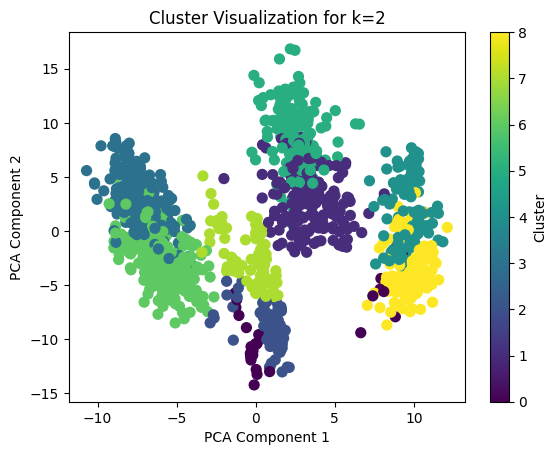

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.scatter(X_pca[:, 0], X_pca[:, 1], c=kmeans.labels_, cmap='viridis', s=50)
plt.colorbar(label='Cluster')
plt.title('Cluster Visualization for k=2')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.show()


## DBSCAN

Let's try the DBSCAN, maybe it will show better result.

No valid clusters were found by DBSCAN for Silhouette Score calculation.


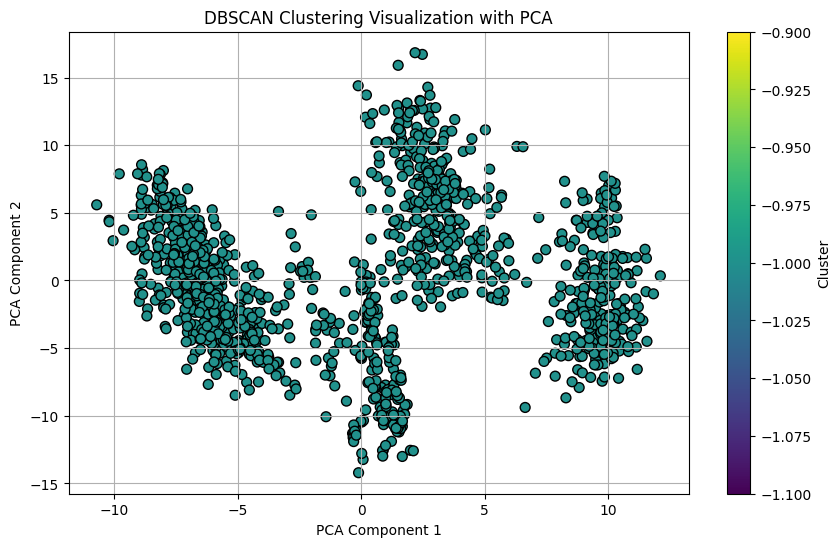

In [ ]:
from sklearn.cluster import DBSCAN

X = train.copy()

dbscan = DBSCAN(eps=0.6, min_samples=4)

labels = dbscan.fit_predict(X)

X['Cluster'] = labels

if len(set(labels)) > 1 and len(set(labels) - {-1}) > 1:  # Ensure more than one cluster is found, excluding noise (-1)
    sil_score = silhouette_score(X[X['Cluster'] != -1].drop(columns=['Cluster']), labels[labels != -1])
    print(f"Silhouette Score: {sil_score}")
else:
    print("No valid clusters were found by DBSCAN for Silhouette Score calculation.")

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X.drop(columns=['Cluster'], errors='ignore'))  # Exclude 'Cluster' column for PCA

plt.figure(figsize=(10, 6))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=labels, cmap='viridis', s=50, edgecolor='k')
plt.colorbar(scatter, label='Cluster')
plt.title('DBSCAN Clustering Visualization with PCA')
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.grid(True)
plt.show()

DBSCAN also didn't provide a good result.

## Decision Tree

Let's try Decision Tree classifier first.

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

y = y_train_class
X = train

X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

clf = DecisionTreeClassifier(random_state=42)

clf.fit(X_train, y_train)

y_pred = clf.predict(X_val)

accuracy = accuracy_score(y_val, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("Confusion Matrix:")
print(confusion_matrix(y_val, y_pred))

print("Classification Report:")
print(classification_report(y_val, y_pred))

Accuracy: 0.74
Confusion Matrix:
[[ 51   1  15]
 [  0  55  18]
 [ 13  27 108]]
Classification Report:
              precision    recall  f1-score   support

           0       0.80      0.76      0.78        67
           1       0.66      0.75      0.71        73
           2       0.77      0.73      0.75       148

    accuracy                           0.74       288
   macro avg       0.74      0.75      0.74       288
weighted avg       0.75      0.74      0.74       288



In [ ]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=3)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5}
Best Accuracy Score: 0.7686956521739131


For classifier we got accuracy score of 0.77, good result.

Let's try Decision Tree Regressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = train
y = y_train_reg

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

regressor = DecisionTreeRegressor(random_state=42)

regressor.fit(X_train, y_train)

y_pred = regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

feature_importances = pd.Series(regressor.feature_importances_, index=X.columns)
print(feature_importances.sort_values(ascending=False))

Mean Squared Error: 0.03388706458799281
R² Score: 0.760118464033402
OverallQual          0.477354
TotalSF              0.289909
YearRemodAdd         0.023726
GarageArea           0.020562
GrLivArea            0.020157
                       ...   
HouseStyle_SLvl      0.000000
HouseStyle_SFoyer    0.000000
HouseStyle_2.5Fin    0.000000
HouseStyle_1.5Unf    0.000000
Condition2_PosN      0.000000
Length: 217, dtype: float64


In [ ]:
param_grid = {
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['squared_error', 'friedman_mse']
}

grid_search = GridSearchCV(DecisionTreeRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=3)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)

Fitting 5 folds for each of 72 candidates, totalling 360 fits
Best Parameters: {'criterion': 'squared_error', 'max_depth': 10, 'min_samples_leaf': 4, 'min_samples_split': 10}
Best R² Score: 0.765010678138643


The MSE is not bad, and pretty small, while R2 score could've been better. Let's check the other models first, and see which will have the best performance.

## Random Forests

First, we will go for Random Forests Classifier

In [ ]:
from sklearn.ensemble import RandomForestClassifier

X = train.copy()
y = y_train_class

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_classifier = RandomForestClassifier(n_estimators=100, random_state=42)

rf_classifier.fit(X_train, y_train)

y_pred = rf_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.86
Classification Report:
              precision    recall  f1-score   support

           0       0.92      0.87      0.89        67
           1       0.85      0.77      0.81        73
           2       0.84      0.90      0.87       148

    accuracy                           0.86       288
   macro avg       0.87      0.84      0.85       288
weighted avg       0.86      0.86      0.86       288

Confusion Matrix:
[[ 58   0   9]
 [  0  56  17]
 [  5  10 133]]


In [ ]:
param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestClassifier(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=3)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 1, 'min_samples_split': 10, 'n_estimators': 100}
Best Accuracy Score: 0.8434782608695652


Random forest classification gave the best result so far.

Let's try Random Forests Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

X = train.copy()
y = y_train_reg

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)

rf_regressor.fit(X_train, y_train)

y_pred = rf_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

feature_importances = pd.Series(rf_regressor.feature_importances_, index=X.columns)
print("Feature Importances:")
print(feature_importances.sort_values(ascending=False))

Mean Squared Error: 0.016504950759489625
R² Score: 0.8831638860616357
Feature Importances:
OverallQual          4.058350e-01
TotalSF              3.510379e-01
YearRemodAdd         1.645892e-02
YearBuilt            1.530455e-02
GrLivArea            1.472634e-02
                         ...     
Electrical_FuseP     1.250664e-08
Condition2_RRNn      1.176242e-08
Exterior2nd_Other    0.000000e+00
RoofStyle_Shed       0.000000e+00
Condition2_PosA      0.000000e+00
Length: 217, dtype: float64


In [ ]:
from sklearn.ensemble import RandomForestRegressor

param_grid = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20, 30],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}

grid_search = GridSearchCV(RandomForestRegressor(random_state=42), param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=3)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best Parameters: {'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 200}
Best R² Score: 0.8693363535653184


As we can see, the MSE is 0.0165 which is better than classification result, and the R2 score is 0.883, also the best result so far.

## KNN

Let's start with KNN classification

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler

X = train
y = y_train_class

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_classifier = KNeighborsClassifier(n_neighbors=5)

knn_classifier.fit(X_train_scaled, y_train)

y_pred = knn_classifier.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")

print("Classification Report:")
print(classification_report(y_test, y_pred))

print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.68
Classification Report:
              precision    recall  f1-score   support

           0       0.72      0.58      0.64        67
           1       0.65      0.67      0.66        73
           2       0.69      0.74      0.71       148

    accuracy                           0.68       288
   macro avg       0.69      0.66      0.67       288
weighted avg       0.69      0.68      0.68       288

Confusion Matrix:
[[ 39   2  26]
 [  0  49  24]
 [ 15  24 109]]


In [ ]:
for k in range(1, 21):  # Test k values from 1 to 10
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train_scaled, y_train)
    y_pred = knn.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    print(f"Accuracy for k={k}: {accuracy:.2f}")

Accuracy for k=1: 0.68
Accuracy for k=2: 0.66
Accuracy for k=3: 0.67
Accuracy for k=4: 0.68
Accuracy for k=5: 0.68
Accuracy for k=6: 0.70
Accuracy for k=7: 0.73
Accuracy for k=8: 0.74
Accuracy for k=9: 0.74
Accuracy for k=10: 0.73
Accuracy for k=11: 0.74
Accuracy for k=12: 0.74
Accuracy for k=13: 0.72
Accuracy for k=14: 0.73
Accuracy for k=15: 0.72
Accuracy for k=16: 0.76
Accuracy for k=17: 0.72
Accuracy for k=18: 0.75
Accuracy for k=19: 0.73
Accuracy for k=20: 0.73


In [ ]:
from sklearn.neighbors import KNeighborsClassifier

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(KNeighborsClassifier(), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=3)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 11, 'weights': 'distance'}
Best Accuracy Score: 0.7765217391304348


Not that good results, well, maybe problem is still in how I decided to divide the house prices.

Let's try KNN regressor

In [ ]:
from sklearn.neighbors import KNeighborsRegressor

X = train
y = y_train_reg

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_regressor = KNeighborsRegressor(n_neighbors=4)

knn_regressor.fit(X_train_scaled, y_train)

y_pred = knn_regressor.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Squared Error: 0.04020670494504266
R² Score: 0.715382661330008


In [ ]:
for k in range(1, 11):
    knn = KNeighborsRegressor(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    mse = mean_squared_error(y_test, y_pred)
    print(f"MSE for k={k}: {mse:.4f}")


MSE for k=1: 0.0591
MSE for k=2: 0.0480
MSE for k=3: 0.0472
MSE for k=4: 0.0463
MSE for k=5: 0.0467
MSE for k=6: 0.0464
MSE for k=7: 0.0478
MSE for k=8: 0.0492
MSE for k=9: 0.0504
MSE for k=10: 0.0507


In [ ]:
from sklearn.neighbors import KNeighborsRegressor

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 11],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'manhattan', 'minkowski']
}

grid_search = GridSearchCV(KNeighborsRegressor(), param_grid, cv=5, scoring='r2', n_jobs=-1, verbose=3)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best R² Score:", grid_search.best_score_)

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best Parameters: {'metric': 'manhattan', 'n_neighbors': 5, 'weights': 'distance'}
Best R² Score: 0.7917915756493084


With scaled dataset we got better results (without scaling the highest R2 was 0.66).

## SVM

SVM classifier

In [ ]:
from sklearn.svm import SVC

X = train
y = y_train_class

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

svm_classifier = SVC(kernel='linear', random_state=42)  # Try 'rbf', 'poly', 'sigmoid'
svm_classifier.fit(X_train, y_train)

y_pred = svm_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.85
Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.90      0.90        67
           1       0.81      0.77      0.79        73
           2       0.84      0.86      0.85       148

    accuracy                           0.85       288
   macro avg       0.85      0.84      0.85       288
weighted avg       0.85      0.85      0.85       288

Confusion Matrix:
[[ 60   0   7]
 [  0  56  17]
 [  7  13 128]]


In [ ]:
from sklearn.svm import SVC

param_grid = {
    'C': [0.1, 1, 10, 100],
    'gamma': ['scale', 'auto', 0.1, 1],
    'kernel': ['linear', 'rbf', 'poly', 'sigmoid']
}

grid_search = GridSearchCV(SVC(random_state=42), param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=3)

grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best Accuracy Score:", grid_search.best_score_)

Fitting 5 folds for each of 64 candidates, totalling 320 fits
Best Parameters: {'C': 0.1, 'gamma': 'scale', 'kernel': 'linear'}
Best Accuracy Score: 0.8469565217391304


Not bad, but the Random Forest Classifier is still better.

SVM Regressor

In [ ]:
import pandas as pd
from sklearn.svm import SVR
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score

X = train
y = y_train_reg

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


svr_regressor = SVR(kernel='rbf', C=1, gamma='scale')
svr_regressor.fit(X_train, y_train)

y_pred = svr_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Squared Error: 0.01860193714697109
R² Score: 0.8683196284770369


Good result!

## Multilayer Perceptron

As usual, we will start from MLP classifier

In [ ]:
from sklearn.neural_network import MLPClassifier

X = train
y = y_train_class

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

mlp_classifier = MLPClassifier(hidden_layer_sizes=(100,), max_iter=500, random_state=42)
mlp_classifier.fit(X_train, y_train)

y_pred = mlp_classifier.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2f}")
print("Classification Report:")
print(classification_report(y_test, y_pred))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.80
Classification Report:
              precision    recall  f1-score   support

        High       0.79      0.81      0.80        67
         Low       0.79      0.77      0.78        73
      Medium       0.80      0.80      0.80       148

    accuracy                           0.80       288
   macro avg       0.79      0.79      0.79       288
weighted avg       0.80      0.80      0.80       288

Confusion Matrix:
[[ 54   0  13]
 [  0  56  17]
 [ 14  15 119]]


Not bad, but we got better results in Random Forests and some other models.

MLP Regressor

In [ ]:
from sklearn.neural_network import MLPRegressor

X = train
y = y_train_reg

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

mlp_regressor = MLPRegressor(hidden_layer_sizes=(50, 30), activation='relu', solver='adam', alpha=0.0001, max_iter=1000, random_state=42)
mlp_regressor.fit(X_train, y_train)

y_pred = mlp_regressor.predict(X_test)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"Mean Squared Error: {mse}")
print(f"R² Score: {r2}")

Mean Squared Error: 0.019673609379664052
R² Score: 0.8607334186841051


I tried to tune the SVM and MLP with GridSearch, but seems like it is above of my laptop capabilities, so I will present results that I was able to get by manually tuning.

# Step 3

Results:

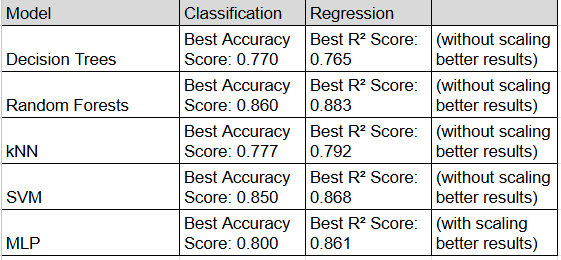

As we can see, the best result is Random Forests Regressor model. Unfortunately the unsupervised learning models didn't perform well (silhouette score is more than 0, but less than 0.25). The problem with classification models could be my personal classifying in the beginning (setting the thresholds for low, medium, and high by considering IQR), so maybe due to k means the 2 clusters are sufficient, but still, the silhouette score is not enough to judge. The regression models behave better because the dataset was initially designed to predict SalePrice, meaning continius data, and Random Forests did a good job there. Probably SVM and MLP would've behave better, but due to my resources limitation, I was not able to make proper tests. The features like OverallQuality, SaleCondition affected models the most. I used GridSearch to find the best parameters (you can check them in the output).